In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data load karna
df = pd.read_csv('heart.csv')

# Data ke shuruati 5 rows dekhna
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


C:\Users\KESHAV DADHICH\AppData\Local\Temp\ipykernel_25236\2610162728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


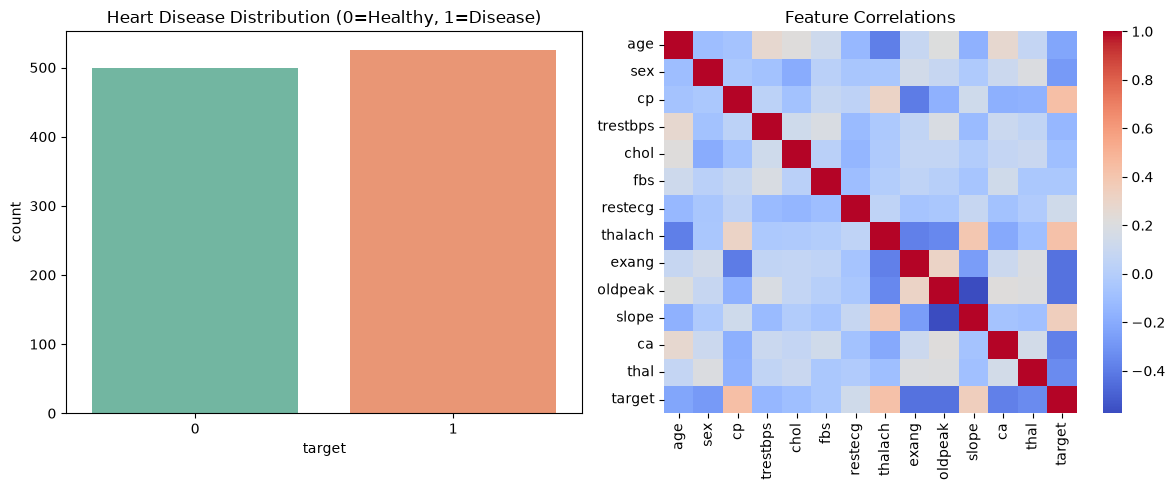

In [2]:
# Cell 2: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Pehla Graph: Kitne healthy hain aur kitno ko disease hai
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Heart Disease Distribution (0=Healthy, 1=Disease)")

# Dusra Graph: Data features ke beech ka relation (Heatmap)
plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlations")

plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X mein se 'target' nikal kar baaki sab rakhenge, y mein sirf 'target'
X = df.drop('target', axis=1)
y = df['target']

# Data ko 80% training aur 20% testing mein baantna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling karna taaki bade numbers (jaise cholesterol) chote numbers par haavi na ho
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Done! Training shape:", X_train_scaled.shape)

Data Preprocessing Done! Training shape: (820, 13)


Model Training Complete! 🎉

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       100
           1       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



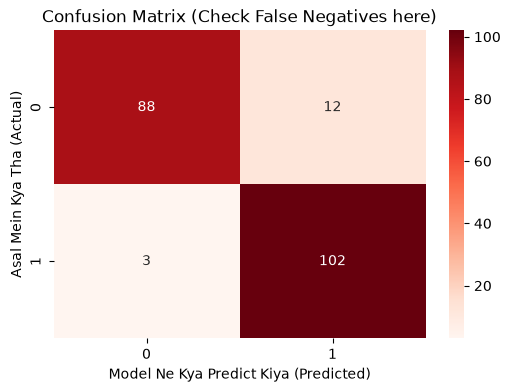

In [4]:
# Cell 4: Model Training aur Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Model Train Karna (max_depth=5 lagaya hai taaki overfitting control ho sake)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Test data par prediction karna
y_pred = rf_model.predict(X_test_scaled)
print("Model Training Complete! 🎉\n")

# 3. Model ka Result (Evaluation)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 4. Confusion Matrix ka Graph (False Negatives check karne ke liye)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Model Ne Kya Predict Kiya (Predicted)')
plt.ylabel('Asal Mein Kya Tha (Actual)')
plt.title('Confusion Matrix (Check False Negatives here)')
plt.show()